In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mat73
import scipy
import numpy as np
import pickle
import pprint

In [ ]:
nameGT25 = r"results\prior\ExcThresh_sealed.mat"
matfGT25 = scipy.io.loadmat(nameGT25)

dict_keys(['__header__', '__version__', '__globals__', 'ExcThresh'])
number of axons in head model: (7358,)
number of axons in head model: (10112,)
number of axons in head model: (13077,)


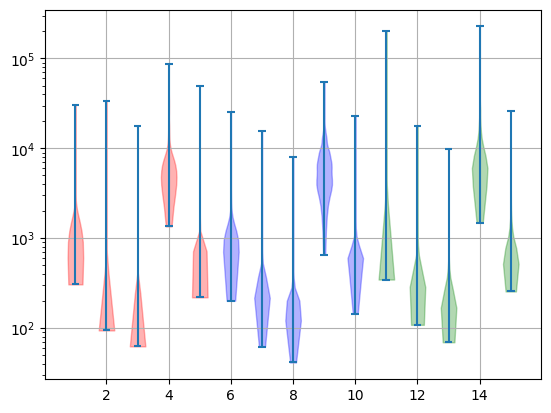

In [ ]:
"gomez-tames 2025 plots"

print(matfGT25.keys())
# print(matf['ExcThresh'])
variablesGT25 = matfGT25['ExcThresh'][0][0] #P1,F2_004TO,F2_005,freqs,modelNames


E_factors = np.array([[0.0783,0.07758,0.07712,0.07513,0.07213],[0.0805,0.07982,0.07938,0.07725,0.07375],[0.0838,0.08289,0.08235,0.08018,0.07657]])
colors = ['r','b','g']

violins = []
for i in range(3):
    for j in range(5):
        matrGT25 = matfGT25['ExcThresh'][0][0][i][0][0][j][:,4]*E_factors[i,4]
        violins += [matrGT25]
    print(f'number of axons in head model: {matrGT25.shape}')
parts = plt.violinplot(violins)


for idx, body in enumerate(parts['bodies']):
    group = idx // 5          # 0, 1, 2
    body.set_facecolor(colors[group])
    body.set_edgecolor(colors[group])
    #body.set_alpha(0.7)

plt.grid()
plt.yscale('log')
plt.show()

dict_keys(['__header__', '__version__', '__globals__', 'G_FH', 'G_FH_37', 'G_SRB', 'G_SRB_37', 'MRG_Motor', 'MRG_Motor_37', 'MRG_Original_16um', 'MRG_Sensory', 'MRG_Sensory_37', 'R_SENN_FH', 'S_FH', 'S_FH_37'])


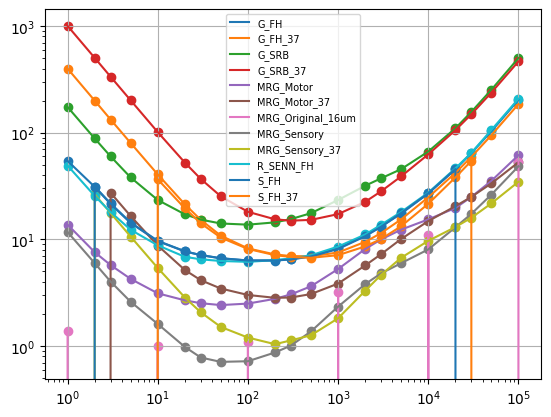

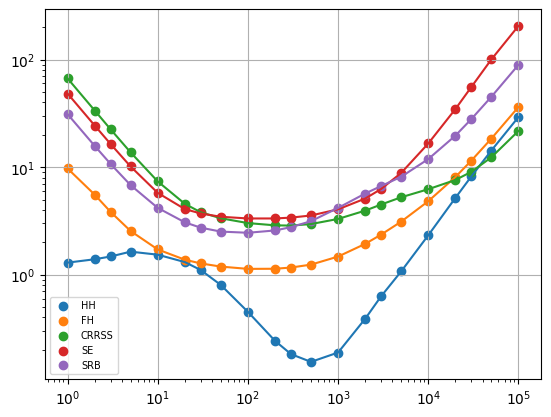

In [ ]:
nameS25 = r"rsults\prior\results SENN comparison.mat"
matfS25 = scipy.io.loadmat(nameS25)
print(matfS25.keys())
Soyka_models = ['G_FH', 'G_FH_37', 'G_SRB', 'G_SRB_37', 'MRG_Motor', 'MRG_Motor_37', 'MRG_Original_16um', 'MRG_Sensory', 'MRG_Sensory_37', 'R_SENN_FH', 'S_FH', 'S_FH_37']
considered_Soyka_models = Soyka_models #['MRG_Original_16um']

for model in considered_Soyka_models:
    plt.plot(matfS25[model][:,0],matfS25[model][:,1],label=model)
    plt.scatter(matfS25[model][:,0],matfS25[model][:,1])

plt.grid()
plt.yscale('log')
plt.xscale('log')
#plt.xlim(100,100000)
plt.legend(fontsize=7)
plt.show()

nameS25_2 = r"results\prior\results BioEM 2022 membranes.mat"
matfS25_2 = scipy.io.loadmat(nameS25_2)

models = ['HH', 'FH', 'CRRSS', 'SE', 'SRB']
for i in range(5):
    threshs = matfS25_2['results'][i::5,-1]
    freqs = matfS25_2['results'][i::5,6]
    plt.plot(freqs,threshs)
    plt.scatter(freqs,threshs,label=models[i])
plt.grid()
plt.yscale('log')
plt.xscale('log')
#plt.xlim(100,100000)
plt.legend(fontsize=7)
plt.show()


(11, 25, 3, 10, 10)
(8250, 10)


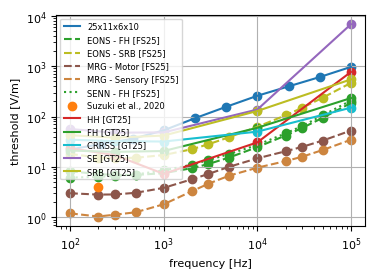

In [ ]:
def color(name):
    color = 'tab:red' if 'HH' in name else 'tab:green' if 'FH' in name else 'tab:cyan' if 'CRRSS' in name else 'tab:purple' if 'SE' in name else 'tab:olive' if 'SRB' in name else 'tab:brown' if 'Motor' in name else 'peru' if 'Sensory' in name else 'k'
    return color

cells = [cel for cel in range(1,26)]
subjects = [3,7,12,17,18,19,20,21,22,23,24]
directions = ['lateral', 'superior', 'anterior']
len_loc = 10
len_freq = 10

freq_array = np.logspace(2,5,200) #np.logspace(2,5,200)

#ICES
E0_unres = 5.89*1e-3
E0_res = 1.77*1e-2
DRL_ICES_unres = np.array([E0_unres if freq < 20 else E0_unres*freq/20 for freq in freq_array])
DRL_ICES_res = np.array([E0_res if freq < 20 else E0_res*freq/20 for freq in freq_array])
#ICNIRP
BS_ICNIRP_occ_CNS = np.array([0.5/freq if freq < 10 else 0.05 if freq <25 else 2*1e-3*freq if freq < 400 else 0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
#BS_ICNIRP_occ_PNS = np.array([0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
BS_ICNIRP_gen_CNS = np.array([0.1/freq if freq < 10 else 0.01 if freq <25 else 4*1e-4*freq if freq < 1000 else 0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])
#BS_ICNIRP_gen_PNS = np.array([0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])

#guidelines plotting
plot_gl = 0
if plot_gl:
    plt.loglog(freq_array,DRL_ICES_res,'-.',label='ICES_restricted') #occupational
    plt.loglog(freq_array,DRL_ICES_unres,':',label='ICES_unrestricted') #general
    plt.loglog(freq_array,BS_ICNIRP_occ_CNS,'-.',label='ICNIRP_occupational_CNS') #occupational CNS
    #plt.loglog(freq_array,BS_ICNIRP_occ_PNS,'-.',label='ICNIRP_occupational_PNS') #occupational PNS   
    plt.loglog(freq_array,BS_ICNIRP_gen_CNS,':',label='ICNIRP_general_CNS') #occupational CNS
    #plt.loglog(freq_array,BS_ICNIRP_gen_PNS,':',label='ICNIRP_general_PNS') #occupational PNS 

all_freqs, all_threshs = np.empty((len(subjects),len(cells),len(directions),len_loc,len_freq)), np.empty((len(subjects),len(cells),len(directions),len_loc,len_freq)) #directions, locations*subjects, frequencies

for isub, subject in enumerate(subjects):
    freqs, threshs = np.empty((len(cells),len(directions),len_loc,len_freq)), np.empty((len(cells),len(directions),len_loc,len_freq))
    for ic,cell in enumerate(cells): 
        for id,direction in enumerate(directions): 
            with open(rf"results\FEM\interpol_linear_logspace_(10, 2, 5)_cell_nr_{cell}_dt_fact_100_subject_{subject}_direction_{direction}.pkl",'rb') as f:
                pkl = pickle.load(f)
            hs300 = pkl['hotspot_300']
            hs100k = pkl['hotspot_100k']

            if sum(hs300[0]['location']==hs100k[0]['location']) == 3:
                for iloc,val300 in enumerate(hs300.values()): #10 locations
                    freq = val300['freq']
                    thresh = val300['thresh']
                    freqs[ic,id,iloc] = freq 
                    threshs[ic,id,iloc] = thresh
            else:
                for iloc, (val300, val100k) in enumerate(zip(hs300.values(),hs100k.values())): #10 locations
                    freq = val300['freq']
                    thresh = np.min((val300['thresh'], val100k['thresh']),axis=0)
                    freqs[ic,id,iloc] = freq
                    threshs[ic,id,iloc] = thresh
    all_freqs[isub] = freqs #id
    all_threshs[isub] = threshs
print(all_threshs.shape)
threshs_flat = all_threshs.reshape(-1,10)
print(threshs_flat.shape)
qmin = np.quantile(threshs_flat,0/4,axis=0)
q50 = np.quantile(threshs_flat,2/4,axis=0)
qmax = np.quantile(threshs_flat,4/4,axis=0)

plt.scatter(freq,q50)
plt.plot(freq,q50,label='25x11x6x10',color='tab:blue') #,color='r', label = all_threshs.shape
#plt.fill_between(freq,qmin,qmax,alpha=0.3,color='b')






"Soyka 2025"
Soyka_models = ['G_FH', 'G_FH_37', 'G_SRB', 'G_SRB_37', 'MRG_Motor', 'MRG_Motor_37', 'MRG_Original_16um', 'MRG_Sensory', 'MRG_Sensory_37', 'R_SENN_FH', 'S_FH', 'S_FH_37']
considered_Soyka_models = ['G_FH_37', 'G_SRB_37', 'MRG_Motor_37', 'MRG_Sensory_37', 'R_SENN_FH', 'S_FH_37']#['MRG_Original_16um']
reconsidered_Soyka_models = ['G_FH_37', 'G_SRB_37', 'MRG_Motor_37', 'MRG_Sensory_37', 'R_SENN_FH'] #'S_FH_37'
#print(matfS25['S_FH_37']) -> contains zeroes
name_mapping_Soyka = {'G_FH_37' : 'EONS - FH', 'G_SRB_37':'EONS - SRB', 'MRG_Motor_37': 'MRG - Motor', 'MRG_Sensory_37': 'MRG - Sensory', 'R_SENN_FH': 'SENN - FH'}
#G: Gent, S: Soyka, FH: Frankenhaeuser Huxley, SRB: Schwarz-Reid-Bostock, SENN: Spatially Extended Nonlinear Node

for model in reconsidered_Soyka_models:
    if 'SENN' in model:
        p = plt.plot(matfS25[model][8:,0],matfS25[model][8:,1],label=name_mapping_Soyka[model]+' [FS25]',color=color(model),ls='dotted')
    else: 
        p = plt.plot(matfS25[model][8:,0],matfS25[model][8:,1],label=name_mapping_Soyka[model]+' [FS25]',color=color(model),ls='dashed')
    #color = p[0].get_color()
    plt.scatter(matfS25[model][8:,0],matfS25[model][8:,1],c=color(model))#,c=color)



"Suzuki 2020"
plt.scatter(200,4,label='Suzuki et al., 2020 ',color='tab:orange') #(nerve cells in the cerebral cortex of rat fetuses) #RMS?



"Gomez-Tames 2025"
medians_GT25 = np.empty((5,3,5))
mins_GT25 = np.empty((5,3,5))
maxs_GT25 = np.empty((5,3,5))
freqs = [1e2,3*1e2,1e3,1e4,1e5]#matfGT25['ExcThresh'][0][0][3]

for ifr, freq in enumerate(freqs):
    for i in range(3):
        for j in range(5):
            matr = matfGT25['ExcThresh'][0][0][i][0][0][j][:,ifr]*E_factors[i,ifr]
            medians_GT25[ifr,i,j] = np.median(matr)
            mins_GT25[ifr,i,j] = np.min(matr)
            maxs_GT25[ifr,i,j] = np.max(matr)
            #plt.scatter(freqs[ifr],np.mean(matr),c=colors[i])

medians_frGT25 = np.median(medians_GT25,axis=(1,2))
mins_frGT25 = np.min(medians_GT25,axis=(1,2))
maxs_frGT25 = np.max(medians_GT25,axis=(1,2))
# plt.plot(freqs,medians_frGT25,c='k',label='Gomez-Tames et al., 2025')
# plt.scatter(freqs,medians_frGT25,c='k')
#plt.fill_between(freqs,mins_frGT25,maxs_frGT25,color='k',alpha=0.3)

'separate'
models = ['HH', 'FH', 'CRRSS', 'SE', 'SRB']
for i in range(5):
    medians_frGT25_model = np.median(medians_GT25[:,:,i],axis=1)
    plt.plot(freqs,medians_frGT25_model,label=models[i]+' [GT25]',color=color(models[i]))
    plt.scatter(freqs,medians_frGT25_model,c=color(models[i]))


"plot enhancer"
plt.xlabel('frequency [Hz]',fontsize = 8)
plt.ylabel('threshold [V/m]',fontsize = 8)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend(loc='upper left',fontsize=6)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
plt.tight_layout()
plt.show()

(11, 25, 3, 10, 10)
(8250, 10)


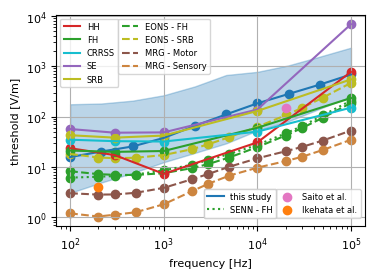

In [ ]:
def color(name):
    color = 'tab:red' if 'HH' in name else 'tab:green' if 'FH' in name else 'tab:cyan' if 'CRRSS' in name else 'tab:purple' if 'SE' in name else 'tab:olive' if 'SRB' in name else 'tab:brown' if 'Motor' in name else 'peru' if 'Sensory' in name else 'k'
    return color

cells = [cel for cel in range(1,26)]
subjects = [3,7,12,17,18,19,20,21,22,23,24]
directions = ['lateral', 'superior', 'anterior']
len_loc = 10
len_freq = 10

freq_array = np.logspace(2,5,200) #np.logspace(2,5,200)

#ICES
E0_unres = 5.89*1e-3
E0_res = 1.77*1e-2
DRL_ICES_unres = np.array([E0_unres if freq < 20 else E0_unres*freq/20 for freq in freq_array])
DRL_ICES_res = np.array([E0_res if freq < 20 else E0_res*freq/20 for freq in freq_array])
#ICNIRP
BS_ICNIRP_occ_CNS = np.array([0.5/freq if freq < 10 else 0.05 if freq <25 else 2*1e-3*freq if freq < 400 else 0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
#BS_ICNIRP_occ_PNS = np.array([0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
BS_ICNIRP_gen_CNS = np.array([0.1/freq if freq < 10 else 0.01 if freq <25 else 4*1e-4*freq if freq < 1000 else 0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])
#BS_ICNIRP_gen_PNS = np.array([0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])

#guidelines plotting
plot_gl = 0
if plot_gl:
    plt.loglog(freq_array,DRL_ICES_res,'-.',label='ICES_restricted') #occupational
    plt.loglog(freq_array,DRL_ICES_unres,':',label='ICES_unrestricted') #general
    plt.loglog(freq_array,BS_ICNIRP_occ_CNS,'-.',label='ICNIRP_occupational_CNS') #occupational CNS
    #plt.loglog(freq_array,BS_ICNIRP_occ_PNS,'-.',label='ICNIRP_occupational_PNS') #occupational PNS   
    plt.loglog(freq_array,BS_ICNIRP_gen_CNS,':',label='ICNIRP_general_CNS') #occupational CNS
    #plt.loglog(freq_array,BS_ICNIRP_gen_PNS,':',label='ICNIRP_general_PNS') #occupational PNS 

all_freqs, all_threshs = np.empty((len(subjects),len(cells),len(directions),len_loc,len_freq)), np.empty((len(subjects),len(cells),len(directions),len_loc,len_freq)) #directions, locations*subjects, frequencies

for isub, subject in enumerate(subjects):
    freqs, threshs = np.empty((len(cells),len(directions),len_loc,len_freq)), np.empty((len(cells),len(directions),len_loc,len_freq))
    for ic,cell in enumerate(cells): 
        for id,direction in enumerate(directions): 
            with open(rf"results\FEM\interpol_linear_logspace_(10, 2, 5)_cell_nr_{cell}_dt_fact_100_subject_{subject}_direction_{direction}.pkl",'rb') as f:
                pkl = pickle.load(f)
            hs300 = pkl['hotspot_300']
            hs100k = pkl['hotspot_100k']

            if sum(hs300[0]['location']==hs100k[0]['location']) == 3:
                for iloc,val300 in enumerate(hs300.values()): #10 locations
                    freq = val300['freq']
                    thresh = val300['thresh']/np.sqrt(2) #RMS
                    freqs[ic,id,iloc] = freq 
                    threshs[ic,id,iloc] = thresh
            else:
                for iloc, (val300, val100k) in enumerate(zip(hs300.values(),hs100k.values())): #10 locations
                    freq = val300['freq']
                    thresh = np.min((val300['thresh'], val100k['thresh']),axis=0)/np.sqrt(2) #RMS
                    freqs[ic,id,iloc] = freq
                    threshs[ic,id,iloc] = thresh
    all_freqs[isub] = freqs #id
    all_threshs[isub] = threshs
print(all_threshs.shape)
threshs_flat = all_threshs.reshape(-1,10)
print(threshs_flat.shape)
qmin = np.quantile(threshs_flat,0/4,axis=0)
q50 = np.quantile(threshs_flat,2/4,axis=0)
qmax = np.quantile(threshs_flat,4/4,axis=0)

plt.scatter(freq,q50)
plt.plot(freq,q50,label='this study',color='tab:blue') #,color='r', label = all_threshs.shape
plt.fill_between(freq,qmin,qmax,alpha=0.3,color='tab:blue')






"Soyka 2025"
Soyka_models = ['G_FH', 'G_FH_37', 'G_SRB', 'G_SRB_37', 'MRG_Motor', 'MRG_Motor_37', 'MRG_Original_16um', 'MRG_Sensory', 'MRG_Sensory_37', 'R_SENN_FH', 'S_FH', 'S_FH_37']
considered_Soyka_models = ['G_FH_37', 'G_SRB_37', 'MRG_Motor_37', 'MRG_Sensory_37', 'R_SENN_FH', 'S_FH_37']#['MRG_Original_16um']
reconsidered_Soyka_models = ['G_FH_37', 'G_SRB_37', 'MRG_Motor_37', 'MRG_Sensory_37', 'R_SENN_FH'] #'S_FH_37'
#print(matfS25['S_FH_37']) -> contains zeroes
name_mapping_Soyka = {'G_FH_37' : 'EONS - FH', 'G_SRB_37':'EONS - SRB', 'MRG_Motor_37': 'MRG - Motor', 'MRG_Sensory_37': 'MRG - Sensory', 'R_SENN_FH': 'SENN - FH'} #Tarnaud2022eons, Tarnaud2022eons, Gaines2018mrg, Gaines2018mrg, Reilly2011SENN
#G: Gent, S: Soyka, FH: Frankenhaeuser Huxley, SRB: Schwarz-Reid-Bostock, SENN: Spatially Extended Nonlinear Node

for model in reconsidered_Soyka_models:
    if 'SENN' in model:
        p = plt.plot(matfS25[model][8:,0],matfS25[model][8:,1],label=name_mapping_Soyka[model],color=color(model),ls='dotted') #Soyka2025AP
    else: 
        p = plt.plot(matfS25[model][8:,0],matfS25[model][8:,1],label=name_mapping_Soyka[model],color=color(model),ls='dashed') #Soyka2025AP
    #color = p[0].get_color()
    plt.scatter(matfS25[model][8:,0],matfS25[model][8:,1],c=color(model))#,c=color)

"Saito 2018"
plt.scatter(20000,147,label='Saito et al.',color='tab:pink') #(nerve cells in the cerebral cortex of rat fetuses) #RMS?

"Suzuki 2020"
plt.scatter(200,4,label='Ikehata et al.',color='tab:orange') #(nerve cells in the cerebral cortex of rat fetuses) #RMS?




"Gomez-Tames 2025"
medians_GT25 = np.empty((5,3,5))
mins_GT25 = np.empty((5,3,5))
maxs_GT25 = np.empty((5,3,5))
freqs = [1e2,3*1e2,1e3,1e4,1e5]#matfGT25['ExcThresh'][0][0][3]

for ifr, freq in enumerate(freqs):
    for i in range(3):
        for j in range(5):
            matr = matfGT25['ExcThresh'][0][0][i][0][0][j][:,ifr]*E_factors[i,ifr]
            medians_GT25[ifr,i,j] = np.median(matr)
            mins_GT25[ifr,i,j] = np.min(matr)
            maxs_GT25[ifr,i,j] = np.max(matr)
            #plt.scatter(freqs[ifr],np.mean(matr),c=colors[i])

medians_frGT25 = np.median(medians_GT25,axis=(1,2))
mins_frGT25 = np.min(medians_GT25,axis=(1,2))
maxs_frGT25 = np.max(medians_GT25,axis=(1,2))
# plt.plot(freqs,medians_frGT25,c='k',label='Gomez-Tames et al., 2025')
# plt.scatter(freqs,medians_frGT25,c='k')
#plt.fill_between(freqs,mins_frGT25,maxs_frGT25,color='k',alpha=0.3)

'separate'
models = ['HH', 'FH', 'CRRSS', 'SE', 'SRB']
for i in range(5):
    medians_frGT25_model = np.median(medians_GT25[:,:,i],axis=1)
    plt.plot(freqs,medians_frGT25_model,label=models[i],color=color(models[i])) #Reilly1998SENN, GT2025IF
    plt.scatter(freqs,medians_frGT25_model,c=color(models[i]))


"plot enhancer"
plt.xlabel('frequency [Hz]',fontsize = 8)
plt.ylabel('threshold [V/m]',fontsize = 8)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.xscale('log')
plt.yscale('log')
plt.grid()



from matplotlib.lines import Line2D

ax = plt.gca()

# Gather handles and labels
handles, labels = ax.get_legend_handles_labels()

# Groups
dashed_h, dashed_l = [], []
non_gt25_h, non_gt25_l = [], []
rest_h, rest_l = [], []
bottom_mid_h, bottom_mid_l = [], []

def is_dashed(h):
    return isinstance(h, Line2D) and h.get_linestyle() in ['--', '-.']

def has_gt25(label):
    return ' ' not in str(label) and '-' not in str(label)

def is_bottom_middle(label):
    """Labels that should go into the bottom middle group."""
    lab = str(label)
    return lab == 'this study' or ('SENN' in lab)

# Split into four groups
for h, lab in zip(handles, labels):

    # Group D: 'this study' or containing 'SENN'
    if is_bottom_middle(lab):
        bottom_mid_h.append(h)
        bottom_mid_l.append(lab)
        continue

    # Group B: dashed or dash-dot
    if is_dashed(h):
        dashed_h.append(h)
        dashed_l.append(lab)
        continue

    # Group A: GT25 but not dashed → upper-left
    if has_gt25(lab):
        rest_h.append(h)
        rest_l.append(lab)
    else:
        # Group C: non-GT25 that are not dashed → lower-right
        non_gt25_h.append(h)
        non_gt25_l.append(lab)


# --- Legend A: GT25 non-dashed (upper-left) ---
if rest_h:
    legA = ax.legend(rest_h, rest_l, loc='upper left', fontsize=6, frameon=True)
    ax.add_artist(legA)

# --- Legend B: dashed (upper-center) ---
if dashed_h:
    legB = ax.legend(
        dashed_h, dashed_l,
        loc='upper center',
        bbox_to_anchor=(0.35, 1.00),
        fontsize=6,
        frameon=True
    )
    ax.add_artist(legB)

# --- Legend C: non-GT25 non-dashed (lower-right) ---
if non_gt25_h:
    legC = ax.legend(
        non_gt25_h, non_gt25_l,
        loc='lower right',
        bbox_to_anchor=(1.0, 0.02),
        fontsize=6,
        frameon=True
    )
    ax.add_artist(legC)

# --- NEW Legend D: 'this study' or containing 'SENN' (bottom-center) ---
if bottom_mid_h:
    legD = ax.legend(
        bottom_mid_h, bottom_mid_l,
        loc='lower center',
        bbox_to_anchor=(0.595, 0.02),
        fontsize=6,
        frameon=True
    )
    ax.add_artist(legD)




#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
plt.tight_layout()
plt.show()
